# 01 - Exploratory Data Analysis
Load the retail dataset, inspect columns, missing values, distributions, and time-based patterns.

In [1]:


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv('../data/raw/retail_store_inventory.csv')


In [2]:
def check_df(dataframe, head= 5):
    print("############### HEAD #################")
    print(dataframe.head())
    print("############### TAIL #################")
    print(dataframe.tail())
    #print("############### QUANTILE #################")
    #print(dataframe.quantiles([0.25, 0.5, 0.75]))
    print("############### MISSING VALUE #################")
    print(dataframe.isnull().sum())
    print("############### TYPES #################")
    print(dataframe.dtypes)
    print("############### SHAPE #################")
    print(dataframe.shape)
    print("############### DESCRIBE #################")
    print(dataframe.describe())

In [3]:
check_df(df, 5)
# Date     object

############### HEAD #################
         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001    Groceries  North              231   
1  2022-01-01     S001      P0002         Toys  South              204   
2  2022-01-01     S001      P0003         Toys   West              102   
3  2022-01-01     S001      P0004         Toys  North              469   
4  2022-01-01     S001      P0005  Electronics   East              166   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         127             55           135.47  33.50        20   
1         150             66           144.04  63.01        20   
2          65             51            74.02  27.99        10   
3          61            164            62.18  32.72        10   
4          14            135             9.26  73.64         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  
0             Rainy                  0        

In [4]:
num_cols = [col for col in df.columns if df[col].dtypes != 'object']
num_cols

cat_cols = [col for col in df.columns if( df[col].dtypes == 'object')  ]
cat_cols

['Date',
 'Store ID',
 'Product ID',
 'Category',
 'Region',
 'Weather Condition',
 'Seasonality']

In [5]:
for col in cat_cols:
    print("############### COLUMN: {} #################".format(col))
    print(df[col].value_counts())
    print("########### UNIQUE VALUES #############")
    print(df[col].nunique())

############### COLUMN: Date #################
2022-07-03    100
2022-02-13    100
2022-11-08    100
2023-08-10    100
2022-02-10    100
             ... 
2023-07-16    100
2023-02-15    100
2022-10-08    100
2023-09-16    100
2023-05-03    100
Name: Date, Length: 731, dtype: int64
########### UNIQUE VALUES #############
731
############### COLUMN: Store ID #################
S004    14620
S001    14620
S005    14620
S003    14620
S002    14620
Name: Store ID, dtype: int64
########### UNIQUE VALUES #############
5
############### COLUMN: Product ID #################
P0018    3655
P0007    3655
P0013    3655
P0020    3655
P0015    3655
P0016    3655
P0010    3655
P0014    3655
P0003    3655
P0004    3655
P0005    3655
P0017    3655
P0001    3655
P0011    3655
P0006    3655
P0002    3655
P0008    3655
P0019    3655
P0009    3655
P0012    3655
Name: Product ID, dtype: int64
########### UNIQUE VALUES #############
20
############### COLUMN: Category #################
Furniture      14699
To

In [6]:
print(df['Date'].max())

print(df['Date'].min())

2024-01-01
2022-01-01


In [7]:
df.groupby('Store ID').agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})


Units Sold                                 
                sum        mean  max min         std
Store ID                                            
S001        1975750  135.140219  496   0  108.708785
S002        1987715  135.958618  492   0  108.933513
S003        2022696  138.351300  499   0  109.776069
S004        1979245  135.379275  496   0  107.639338
S005        2010176  137.494938  494   0  109.505703

In [8]:
df.groupby('Product ID').agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})

Units Sold                                 
                  sum        mean  max min         std
Product ID                                            
P0001          498061  136.268399  496   0  109.315675
P0002          487827  133.468399  486   0  106.417492
P0003          493279  134.960055  485   0  108.380437
P0004          495501  135.567989  489   0  109.263223
P0005          503648  137.796990  488   0  106.854998
P0006          497131  136.013953  489   0  108.807250
P0007          499321  136.613133  491   0  110.505351
P0008          488563  133.669767  494   0  108.675121
P0009          502086  137.369631  491   0  110.560806
P0010          496469  135.832832  488   0  109.721355
P0011          499362  136.624350  484   0  108.245989
P0012          491670  134.519836  496   0  107.748105
P0013          500619  136.968263  494   0  108.149168
P0014          507622  138.884268  485   0  110.203837
P0015          507283  138.791518  482   0  109.914956
P0016          508472  139.116826  492   0  109.389823
P0017          500510  136.938440  495   0  107.890733
P0018          492551  134.760876  499   0  108.535957
P0019          497899  136.224077  479   0  109.493124
P0020          507708  138.907798  484   0  110.229782

In [9]:
df.groupby('Category').agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})

Units Sold                                 
                   sum        mean  max min         std
Category                                               
Clothing       1999166  136.685765  489   0  108.421855
Electronics    1960432  135.006680  496   0  108.448033
Furniture      2025017  137.765630  499   0  110.017747
Groceries      2000482  136.916159  494   0  109.256043
Toys           1990485  135.934235  496   0  108.431014

In [10]:
df.groupby('Weather Condition').agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})

Units Sold                                 
                         sum        mean  max min         std
Weather Condition                                            
Cloudy               2497207  136.758324  495   0  108.328539
Rainy                2470455  135.160028  487   0  107.919441
Snowy                2483376  135.911559  499   0  109.379042
Sunny                2524544  138.028650  494   0  110.024762

In [11]:
df.groupby('Region').agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})

Units Sold                                 
              sum        mean  max min         std
Region                                            
East      2511265  136.861137  499   0  109.473085
North     2484966  136.326860  491   0  109.207022
South     2507799  137.060666  489   0  108.959817
West      2471552  135.605838  496   0  108.031480

5 mağaza × 20 ürün = 100 farklı zaman serisi oluşturmak verimsizdir. 
En çok satılan Product'ın Hangi Store'da satıldığını bul. SARIMAX sadece bunun için uygula
# Mevsimselliği dikkate alan geleneksel SARIMAX modeli dışsal değişkenlerin karmaşık etkilerini tolere edemezken, geliştirdiğimiz LightGBM/XGBoost modeli hatayı %X oranında düşürmüştür

In [12]:
df_max = df.groupby(['Store ID', 'Product ID']).agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})

df_max.sort_values(["Store ID","Product ID"], ascending=False)
df_max

Units Sold                                 
                           sum        mean  max min         std
Store ID Product ID                                            
S001     P0001          100371  137.306430  461   0  108.187859
         P0002           95789  131.038304  486   0  104.313220
         P0003          103393  141.440492  484   0  107.211225
         P0004          103001  140.904241  475   0  113.644117
         P0005           97318  133.129959  480   0  107.368873
...                        ...         ...  ...  ..         ...
S005     P0016          101821  139.290014  480   0  111.576662
         P0017          100358  137.288646  484   0  108.617275
         P0018           98064  134.150479  487   0  109.795997
         P0019           98724  135.053352  474   0  108.657996
         P0020          101370  138.673051  484   0  111.140716

[100 rows x 5 columns]

In [13]:
df.groupby(['Holiday/Promotion']).agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})

Units Sold                                 
                         sum        mean  max min         std
Holiday/Promotion                                            
0                    5016163  136.505375  499   0  109.276450
1                    4959419  136.423926  496   0  108.558786

In [14]:

df.groupby(['Date', 'Store ID']).agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})

Units Sold                             
                           sum    mean  max min         std
Date       Store ID                                        
2022-01-01 S001           2762  138.10  369  12  103.928569
           S002           2974  148.70  393   9  123.366847
           S003           3208  160.40  370   4  125.827953
           S004           2505  125.25  382   0  111.155119
           S005           3035  151.75  371   8  108.634043
...                        ...     ...  ...  ..         ...
2024-01-01 S001           2278  113.90  272   9   92.023395
           S002           2264  113.20  347   2  107.349209
           S003           3067  153.35  398   9  112.640684
           S004           2543  127.15  496   1  127.996001
           S005           3092  154.60  324   4  106.299676

[3655 rows x 5 columns]

In [15]:
df.groupby("Month").agg({"Seasonality": "value_counts"})

# Seasonlity feature'ı Month'dan bağımsızdır. Tüm aylar için Seasonality 
# feature'ı aynı değeri alıyor. Bu nedenle, Month ve Seasonality feature'ları 
# arasında bir bağımlılık var. 

KeyError: 'Month'

In [16]:
df.groupby(['Store ID']).agg({'Seasonality': 'value_counts'})

Seasonality
Store ID Seasonality             
S001     Winter              3700
         Summer              3681
         Autumn              3627
         Spring              3612
S002     Spring              3690
         Summer              3654
         Winter              3653
         Autumn              3623
S003     Spring              3683
         Autumn              3652
         Winter              3643
         Summer              3642
S004     Summer              3708
         Winter              3667
         Spring              3662
         Autumn              3583
S005     Autumn              3708
         Spring              3670
         Winter              3622
         Summer              3620

In [ ]:
df.groupby(['Product ID']).agg({'Seasonality': 'value_counts'})

In [ ]:
df.groupby(['Region']).agg({'Seasonality': 'value_counts'})

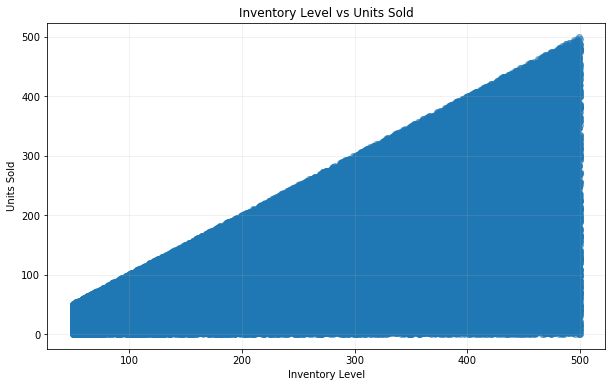

In [17]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Inventory Level"],
    df["Units Sold"],
    alpha=0.5
)

plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")
plt.title("Inventory Level vs Units Sold")

plt.grid(alpha=0.2)
plt.show()

# - Scatter plot üçgen şeklinde: Units Sold hep Inventory Level'ın altında kalıyor
#   (Units Sold ~ Uniform(0, Inventory Level) kısıtı mevcut).
# - Korelasyon = 0.59 (Orta-güçlü, kesinlikle göz ardı edilemez).

In [ ]:
num_cols

In [18]:
def outlier_thresholds(dataframe, col_name, q1 = 0.25, q3 = 0.75):

    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)

    iqr = quartile3 - quartile1
    upper_limit = quartile3 + 1.5 * iqr
    lower_limit = quartile1 - 1.5 * iqr

    return lower_limit, upper_limit

def check_outliers( dataframe, col_name):
    lower_limit, upper_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > upper_limit) | (dataframe[col_name] < lower_limit)].any(axis=None):
        return True
    else:
        return False

def suppress_outliers(dataframe, col_name):
    low_limit, upper_limit = outlier_thresholds(dataframe, col_name)
    dataframe.loc[(dataframe[col_name] < low_limit), col_name] = low_limit
    dataframe.loc[(dataframe[col_name] > upper_limit), col_name] = upper_limit

In [ ]:
for col in num_cols:
    if check_outliers(df, col):
        print(col, "has outliers")
    else:
        print(col, "does not have outliers")

In [ ]:
df_zero = df[df["Units Sold"] == 0]
df_zero

# Zero units sold olan store ID'leri say
df_zero["Store ID"].value_counts()

# Zero units sold olan product ID'leri say
df_zero["Product ID"].value_counts()

In [ ]:
# Seasonality gerçekten doğru mu, check et
from datetime import datetime

"""
df["Date"].dtypes
df['Date'] = df['Date'].astype('datetime64[ns]')
df["Month"] = df["Date"].dt.month
"""

df["Seasonality_NEW"] = df["Date"].apply(lambda x: "Winter" if x.month in [12, 1, 2] else ("Spring" if x.month in [3, 4, 5] else ("Summer" if x.month in [6, 7, 8] else "Fall")))

In [ ]:
df["Seasonality_NEW"].value_counts()


In [ ]:
df["Seasonality"].value_counts()

In [ ]:
df.groupby("Month").agg({"Seasonality": "value_counts"})

# Seasonlity feature'ı Month'dan bağımsızdır. Tüm aylar için Seasonality 
# feature'ı aynı değeri alıyor. Bu nedenle, Month ve Seasonality feature'ları 
# arasında bir bağımlılık var. 

In [ ]:
df['DayOfWeek'] = df['Date'].dt.day_name()

df.groupby('DayOfWeek').agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})

mkl-random 1.0.1 requires cython, which is not installed.
tensorflow 1.10.0 has requirement numpy<=1.14.5,>=1.13.3, but you'll have numpy 1.19.5 which is incompatible.
tensorflow 1.10.0 has requirement setuptools<=39.1.0, but you'll have setuptools 58.0.4 which is incompatible.
You are using pip version 10.0.1, however version 21.3.1 is available.
You should consider upgrading via the 'python -m pip install --upgrade pip' command.


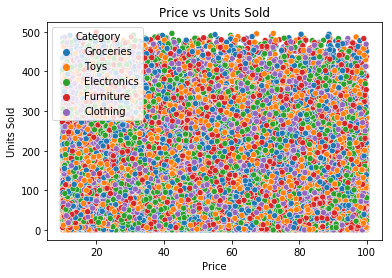

In [19]:
%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(data=df, x='Price', y='Units Sold', hue='Category')
plt.title("Price vs Units Sold")
plt.show()

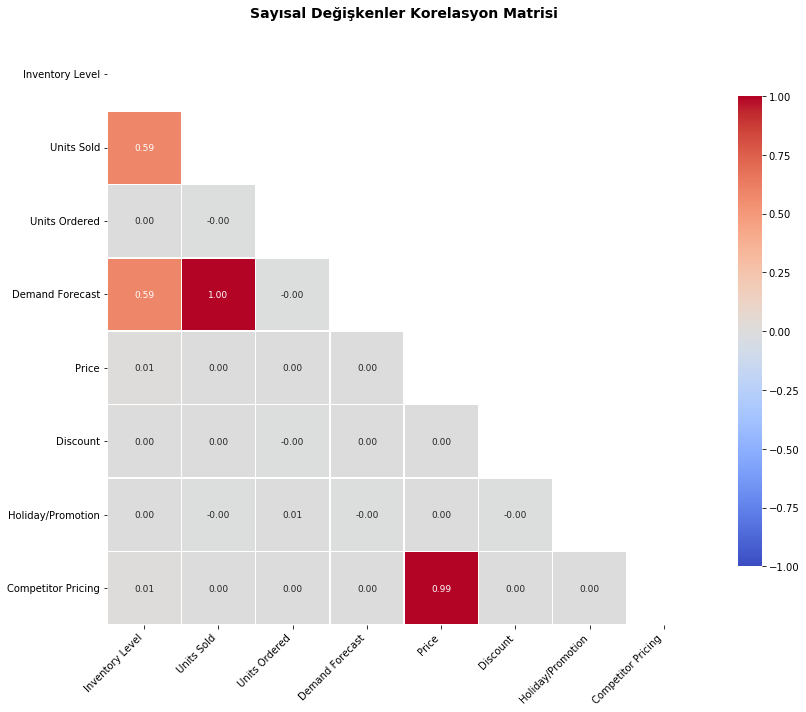

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sadece sayısal sütunları seç (Pandas sürümünden bağımsız güvenli yöntem)
numeric_df = df.select_dtypes(include=[np.number])

# 2. Korelasyon matrisini hesapla
corr = numeric_df.corr()

# 3. Üst üçgeni gizlemek için maske oluştur (diyagonal dahil)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 4. Grafik boyutunu ve stilini ayarlama
plt.figure(figsize=(12, 10))

# 5. Özelleştirilmiş Heatmap
sns.heatmap(
    corr, 
    mask=mask,                # Üst üçgeni gizler
    annot=True,               # Değerleri yazar
    fmt=".2f",                # Virgülden sonra 2 basamak
    cmap="coolwarm",          # Renk paleti
    vmin=-1, vmax=1,          # Skalayı -1 ile 1 arasında sabitler
    center=0,                 # 0 noktasını nötr renk yapar
    linewidths=0.5,           # Hücre aralarına ince çizgi
    linecolor='white',
    cbar_kws={"shrink": 0.8}, # Renk çubuğunu ölçeklendirir
    annot_kws={"size": 9}     # Yazı boyutunu ayarlar
)

plt.title("Sayısal Değişkenler Korelasyon Matrisi", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

# - Units Sold ile Demand Forecast arasındaki korelasyon = 1.00
# - Bu kolon muhtemelen Units Sold + küçük bir gürültü ile üretilmiş.

Demand Forecast,  geçmişe veya mevcut sistemine bakarak Gelecekte satılacak ürün tahminin yapıldığı yer. modeli eğitirken bunu feature olarak verirsek hedefi direkt görmüş olur doğru bir yaklaşım olmaz (Data Leakage)

In [ ]:
# Lag correlation
pd.DataFrame({"Units Sold": df["Units Sold"].values[0:10],
              "lag1": df["Units Sold"].shift(1).values[0:10],
              "lag2": df["Units Sold"].shift(2).values[0:10],
              "lag3": df["Units Sold"].shift(3).values[0:10],
              "lag4": df["Units Sold"].shift(4).values[0:10]})

In [ ]:
# Ürünün x gün önce kaç birim satıldığı bilgisidir.
def lag_features(dataframe, lags):
    for lag in lags:
        dataframe['units_sold_lag_' + str(lag)] = dataframe.groupby(["Store ID", "Product ID"])['Units Sold'].transform(
            lambda x: x.shift(lag)) 
    return dataframe

df = lag_features(df, [1, 2, 3, 7, 14, 30, 365])

In [ ]:
# Ürünün bugünden önceki x gün boyunca günde ortalama kaç adet satıldığı bilgisidir
# Rolling statistics
def roll_mean_features(dataframe, windows):
    for window in windows:
        dataframe['sales_roll_mean_' + str(window)] = (
            dataframe.groupby(["Store ID", "Product ID"])['Units Sold']
            .transform(lambda x: x.shift(1).rolling(window=window).mean())
        )
    return dataframe

# burada shift(1) kullanmamızın sebebi, o günün satışını tahmin etmek 
# için o günün satışını kullanamayız. Bu nedenle, bir önceki günün satışını 
# kullanıyoruz.


In [ ]:
df = roll_mean_features(df, [7, 30])

In [ ]:
df.head()

In [21]:
import pandas as pd
import numpy as np

# df: Store ID, Product ID, Date'e göre sort edilmiş, orijinal (lag eklenmeden önceki) hali
# Bu kontrolü lag feature'ları eklemeden hemen önce, sort_values sonrasında çalıştır

def check_inventory_consistency(dataframe):
    g = dataframe.groupby(['Store ID', 'Product ID'])

    inv = dataframe['Inventory Level']
    inv_lag1 = g['Inventory Level'].shift(1)
    sold_lag1 = g['Units Sold'].shift(1)
    ordered_lag1 = g['Units Ordered'].shift(1)

    # Hipotez A: Inventory Level = AÇILIŞ stoğu
    # Bugünün açılışı = dünün açılışı - dün satılan + dün gelen sipariş
    predicted_opening = inv_lag1 - sold_lag1 + ordered_lag1
    residual_opening = inv - predicted_opening

    # Hipotez B: Inventory Level = KAPANIŞ stoğu
    # Bugünün kapanışı = dünün kapanışı - bugün satılan + bugün gelen sipariş
    sold_today = dataframe['Units Sold']
    ordered_today = dataframe['Units Ordered']
    predicted_closing = inv_lag1 - sold_today + ordered_today
    residual_closing = inv - predicted_closing

    results = pd.DataFrame({
        'residual_opening_hypothesis': residual_opening,
        'residual_closing_hypothesis': residual_closing,
    })

    summary = pd.DataFrame({
        'hypothesis': ['Opening (Açılış)', 'Closing (Kapanış)'],
        'mean_abs_residual': [
            residual_opening.abs().mean(),
            residual_closing.abs().mean()
        ],
        'median_abs_residual': [
            residual_opening.abs().median(),
            residual_closing.abs().median()
        ],
        'pct_within_tolerance_5': [
            (residual_opening.abs() <= 5).mean() * 100,
            (residual_closing.abs() <= 5).mean() * 100
        ]
    })

    return results, summary

residuals, summary = check_inventory_consistency(df)
print(summary)
print()
print(residuals.describe())

          hypothesis  mean_abs_residual  median_abs_residual  \
0   Opening (Açılış)         146.690671                129.0   
1  Closing (Kapanış)         208.459178                182.0   

   pct_within_tolerance_5  
0                2.300958  
1                1.644323  

       residual_opening_hypothesis  residual_closing_hypothesis
count                 73000.000000                 73000.000000
mean                     26.442425                    26.421151
std                     178.042470                   255.482507
min                    -619.000000                  -614.000000
25%                     -96.000000                  -160.000000
50%                      30.000000                    13.000000
75%                     159.000000                   205.000000
max                     466.000000                   899.000000


In [ ]:
# ============================================================
# SMARTSUPPLY AI - FINAL EDA ÇIKARIMLARI & FEATURE ENGINEERING YOL HARİTASI
# ============================================================

# ------------------------------------------------------------
# 1. VERİ SETİ GENEL DURUM
# ------------------------------------------------------------
# - 73.100 satır, 15 sütun | 2022-01-01 - 2024-01-01 (731 gün)
# - 5 Mağaza x 20 Ürün x 731 gün = Tam dengeli panel veri (dengesizlik yok)
# - Eksik değer (null) YOK
# - Veri seti SENTETİK üretilmiş (Kaggle "Retail Store Inventory Forecasting"
#   veri seti ile örtüşüyor). Verideki bazı business ilişkilerinin (fiyat, kampanya vb.)
#   doğal olmadığını ve sentetik noise içerdiğini göz önünde bulunduruyoruz.

# ------------------------------------------------------------
# 2. KRİTİK EDA BULGULARI VE DÜZELTMELER
# ------------------------------------------------------------

# 🔴 BULGU 1 - "Demand Forecast" = TARGET LEAKAGE (EN ÖNEMLİ BULGU)
# - Units Sold ile Demand Forecast arasındaki korelasyon = 1.00
# - Bu kolon muhtemelen Units Sold + küçük bir gürültü ile üretilmiş.
# - Feature olarak kullanılırsa model "cevabı" görmüş olur (Data Leakage).
# - AKSİYON: Bu kolonu feature setinden ÇIKAR.
#   Yalnızca "Naif Baseline" olarak sakla -> Kendi kuracağın modelin
#   başarısını (MAE/RMSE) bu kolonla kıyaslayarak sunumda fark yarat.

# 🔴 BULGU 2 - Inventory Level, Units Sold'u FİİLEN KISITLIYOR
# - Scatter plot üçgen şeklinde: Units Sold hep Inventory Level'ın altında kalıyor
#   (Units Sold ~ Uniform(0, Inventory Level) kısıtı mevcut).
# - Korelasyon = 0.59 (Orta-güçlü, kesinlikle göz ardı edilemez).
# - AKSİYON: Inventory Level'ı güçlü bir sinyal değişkeni olarak tut.

# 🟡 BULGU 3 - Fiyat/Kampanya/Hava Durumu/Bölge
# - Units Sold ile korelasyonları sıfıra yakın (0.001-0.003). Promosyonlu ve
#   promosyonsuz günlerin ortalama satışı aynı (~136 birim).
# - AKSİYON: Değişkenleri modele ekle (ağaç modelleri gürültüden etkilenmez),
#   ancak iş hikayesinde abartılı nedensellik iddialarında bulunma.

# 🟡 BULGU 4 - Multicollinearity Riski (Price vs Competitor Pricing)
# - Price ile Competitor Pricing korelasyonu = 0.99.
# - AKSİYON: İkisini ham haliyle birlikte kullanmak yerine Price_Diff ve
#   Price_Ratio gibi tekil türetilmiş değişkenlere indirge.

# 🔴 BULGU 5 - Orijinal "Seasonality" Kolonu BOZUK / Rastgele
# - Ocak ayında dört mevsim de eşit sayıda görünüyor (Tarihten bağımsız atanmış).
# - AKSİYON: Orijinal Seasonality kolonunu SİL, tarihten yeniden türet.

# 🟡 BULGU 6 - Demand Forecast Negatif Değer Anomalisi
# - Minimum değer -9.99 olarak görülüyor.
# - AKSİYON: np.maximum(0, df['Demand Forecast']) ile 0'a eşitle (Baseline kıyası için).

# 🟠 BULGU 7 - Teknik Borç & Reprodüksiyon
# - Date dönüşümü ve roll_mean_features içindeki ValueError (min_periods) düzeltilmeli.
# - AKSİYON: Dönüşümleri açık hücrelere taşı ve min_periods=1 ile güncelle.

# ------------------------------------------------------------
# 3. PREPROCESSING - YAPILACAKLAR
# ------------------------------------------------------------

# [ ] Date sütununu datetime'a çevir ve veriyi ['Store ID', 'Product ID', 'Date'] sırasına sok
# [ ] Demand Forecast negatif değerlerini 0'a çek (np.maximum)
# [ ] Demand Forecast'ı FEATURE SETİNDEN ÇIKAR (Sadece baseline kıyası için sakla)
# [ ] Orijinal Seasonality kolonunu SİL

# ------------------------------------------------------------
# 4. FEATURE ENGINEERING - YAPILACAKLAR
# ------------------------------------------------------------

# --- A. Zaman Bazlı Feature'lar ---
# [ ] Year, Month, Day, DayOfWeek, Is_Weekend (0/1)
# [ ] Seasonality_NEW: Gerçek aya göre türet
#     (Winter: 12-1-2, Spring: 3-4-5, Summer: 6-7-8, Autumn: 9-10-11)

# --- B. Lag / Rolling Feature'lar (groupby(["Store ID", "Product ID"]) ile) ---
# [ ] Lag_1, Lag_7, Lag_14, Lag_30, Lag_365
# [ ] sales_roll_mean_7, sales_roll_mean_30, sales_roll_std_7
#     -> shift(1) ve min_periods=1 kullanarak hesapla (Leakage önleme).
# NOT: Lag_365 ilk 365 gün için NaN üretecektir (~%36-40 satır). Veri 2 yıllık
# olduğu için kaçınılmazdır. XGBoost/LightGBM NaN değerleri native tolere eder.

# --- C. Stok Bazlı Feature'lar ---
# [ ] Inventory Level'ı olduğu gibi tut (Satış üst sınırını kısıtlıyor)

# --- D. Fiyat / Rekabet Feature'ları ---
# [ ] Net_Price = Price * (1 - Discount/100)
# [ ] Price_Diff_vs_Competitor = Price - Competitor Pricing
# [ ] Price_Ratio = Price / Competitor Pricing
# [ ] Discount_Flag = (Discount > 0).astype(int)

# --- E. Categorical Encoding (Train/Test Split Sonrası) ---
# [ ] Weather Condition, Region, Seasonality_NEW -> One-Hot Encoding
# [ ] Store ID (5), Product ID (20), Category (5) -> Low-cardinality olduğu için
#     Target Encoding riskine girmeden Label Encoding veya Native Categorical kullan.

# ------------------------------------------------------------
# 5. MODEL VALIDATION STRATEJİSİ
# ------------------------------------------------------------
# [ ] Random Split KULLANMA (Zaman serisini bozar).
# [ ] Zaman bazlı ayrım yap: Son 30 gün -> Test Seti (Hold-out), Öncesi -> Train Seti.
# [ ] Model performansını Demand Forecast (Naif Baseline) ile kıyasla (MAE / RMSE).

## Görsel analiz için ek açıklayıcı grafikler
Bu bölümde EDA için daha fazla anlam çıkaran görseller ekleniyor:
- günlük satış trendi
- stok vs satış ilişkisi
- kategori bazlı dağılım
- promosyon etkisi
- korelasyon ısı haritası

mkl-random 1.0.1 requires cython, which is not installed.
tensorflow 1.10.0 has requirement numpy<=1.14.5,>=1.13.3, but you'll have numpy 1.19.5 which is incompatible.
tensorflow 1.10.0 has requirement setuptools<=39.1.0, but you'll have setuptools 58.0.4 which is incompatible.
You are using pip version 10.0.1, however version 21.3.1 is available.
You should consider upgrading via the 'python -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


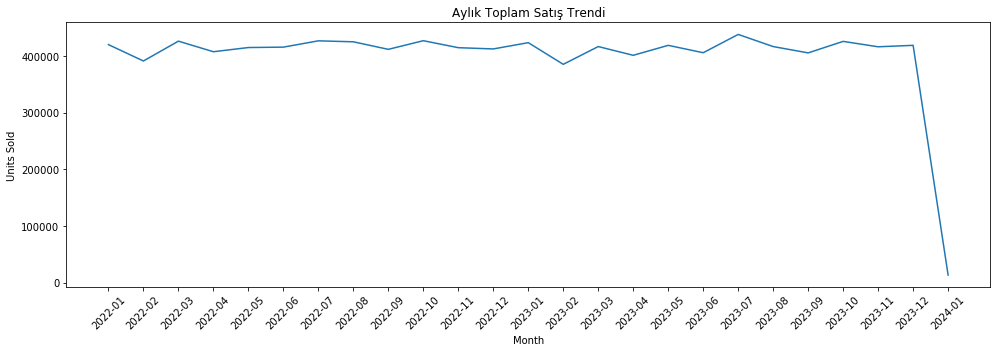

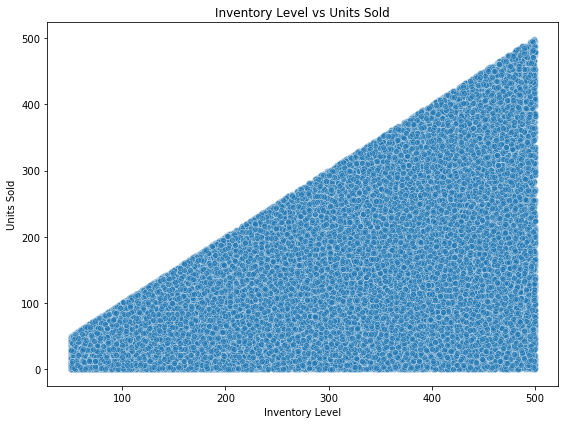

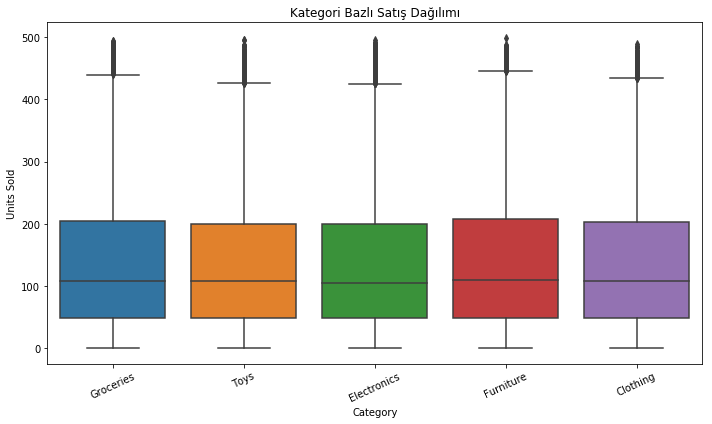

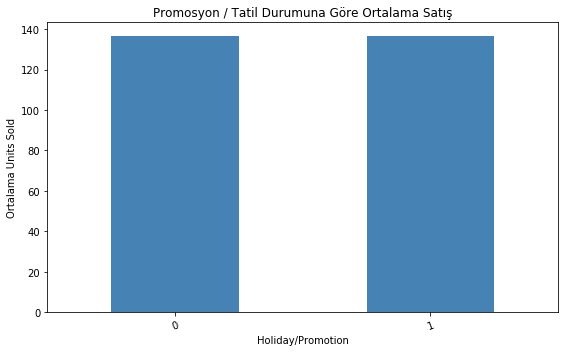

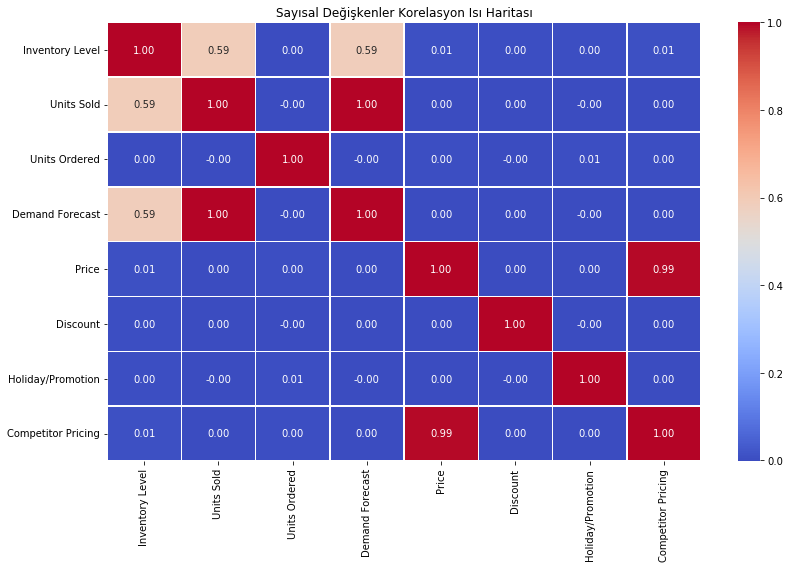

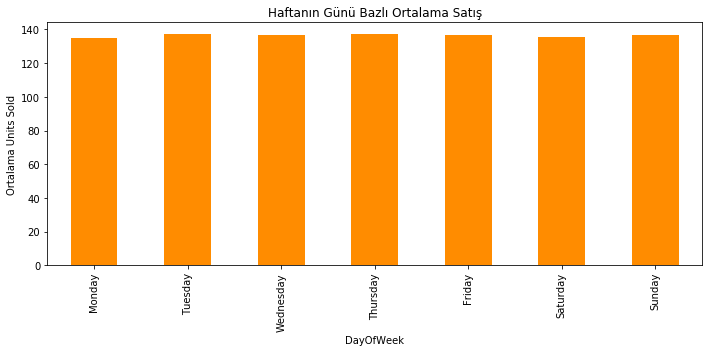

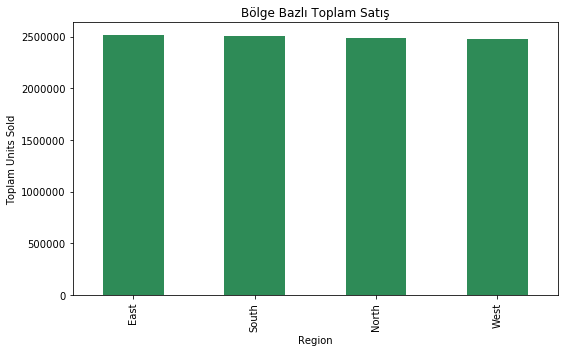

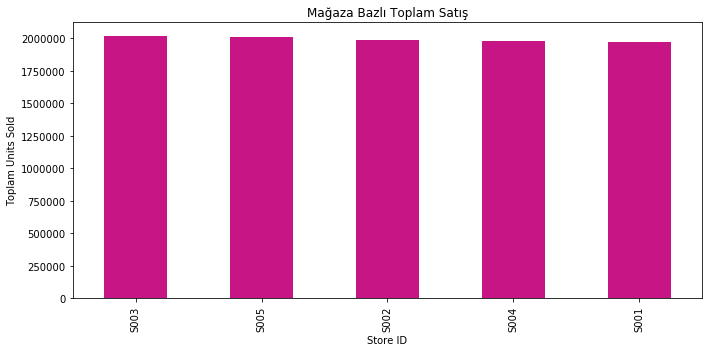

In [22]:
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Tarih sütununu datetime'a dönüştür
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.to_period('M').astype(str)
    df['DayOfWeek'] = df['Date'].dt.day_name()

# 1) Aylık toplam satış trendi
monthly_sales = df.groupby('Month')['Units Sold'].sum().sort_index()
plt.figure(figsize=(14, 5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.xticks(rotation=45)
plt.title('Aylık Toplam Satış Trendi')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

# 2) Stok vs satış scatter
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Inventory Level', y='Units Sold', alpha=0.5)
plt.title('Inventory Level vs Units Sold')
plt.xlabel('Inventory Level')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

# 3) Kategori bazlı satış dağılımı
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Units Sold')
plt.title('Kategori Bazlı Satış Dağılımı')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 4) Promosyon / tatil etkisi
promo_effect = df.groupby('Holiday/Promotion')['Units Sold'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
promo_effect.plot(kind='bar', color='steelblue')
plt.title('Promosyon / Tatil Durumuna Göre Ortalama Satış')
plt.ylabel('Ortalama Units Sold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 5) Korelasyon ısı haritası
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Sayısal Değişkenler Korelasyon Isı Haritası')
plt.tight_layout()
plt.show()

# 6) Haftanın günü bazlı satış ortalaması
weekday_sales = df.groupby('DayOfWeek')['Units Sold'].mean().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])
plt.figure(figsize=(10, 5))
weekday_sales.plot(kind='bar', color='darkorange')
plt.title('Haftanın Günü Bazlı Ortalama Satış')
plt.ylabel('Ortalama Units Sold')
plt.tight_layout()
plt.show()

# 7) Region bazlı toplam satış
region_sales = df.groupby('Region')['Units Sold'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar', color='seagreen')
plt.title('Bölge Bazlı Toplam Satış')
plt.ylabel('Toplam Units Sold')
plt.tight_layout()
plt.show()

# 8) Store bazlı toplam satış
store_sales = df.groupby('Store ID')['Units Sold'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
store_sales.plot(kind='bar', color='mediumvioletred')
plt.title('Mağaza Bazlı Toplam Satış')
plt.ylabel('Toplam Units Sold')
plt.tight_layout()
plt.show()